# Reachability using density:
We call a set of initial states $X_o \subset X$, and an unsafe set $X_u \subset X$ and $X_r \subset X$ be the target set where $X$ is the set of states one can take.
Consider the differential equation :
\begin{align*}
    \dot{x}=f(x,u)
\end{align*}
with $f\in C^1(R^n,R^n)$. Let $X \subset R^n$ and $X_o,X_u,X_r \subset X$ be bounded open sets and suppose that there exists a function $B \in C^1(R^n,R)$ satisfying:
\begin{align}
    \int_{x_o}B(x)dx &< 0\\
    B(x) &>0 \quad \forall x \in \partial X \backslash \partial X_r\\
    \frac{\partial B}{\partial x}f(x) &<0 \quad \forall x \in cl(X \backslash X_r)
\end{align} 
Then the reachability property holds, i.e. there exists a trajectory $x(t)$ of the system such that $x(0) \in X_o, x(T) \in X_r$ for some $T \geq 0$ and $x(t) \in X$ for all $t \in [0,T]$

On the other hand, if there exists a function $\rho \in C^1(R^n,R)$ satisfying
\begin{align}
    \rho(x) \geq 0 \quad \forall x \in X_0\\
    \rho(x) < 0 \quad \forall x \in X_u\\
    \nabla. (\rho f)(x) \geq 0 \quad \forall x \in X
\end{align}
then the safety property holds, i.e. there exists no trajectory such that $x(0) \in X_o$, $x(T)\in X_u$ for some $T\geq 0$ and $x(t) \in X$ for all $t \in [0,T]$.

Prajna's work shows if there exists such a $\rho$, then the safety property holds. And we would like compute such a $\rho$ and eventually utilize this to find a valid trajectory.
We will utilize the same method of learner and verifier here to learn such a $\rho$.

\begin{align*}
    L(\theta)= E_{ x \sim X_o} \left[ 0, -\rho(x) \right] + E_{ x \sim X_u} \left [ 0,\rho(x) \right] + E_{x \sim X} \left[ 0, -\nabla .( \rho(x) f(x)) \right]
\end{align*}

and the SMT constraint should be:
\begin{align*}
    \Phi_{\epsilon}(x):= \left( \sum_{i=1}^{n}x_i^2 \geq \epsilon \right) \wedge ( \rho_{x \in X_u}(x) \geq 0) \wedge (\rho_{x \in X_o}(x) < 0) \wedge ( \nabla . [ (\rho.f)(x)] < 0)
\end{align*}

# Dubin's Car Dynamics:
We will demonstrate our method to evaluate reachability to set $X_r$ given we started at $X_o$ and unsafe set is $X_u$.
\begin{align*}
    f_u(x,y,\theta)&= \begin{bmatrix}
        v \cos(\theta)\\
        v \sin ( \theta)\\
        0
    \end{bmatrix} + \begin{bmatrix}
    0 \\
    0 \\
    1
    \end{bmatrix} u(x,y, \theta)
\end{align*}

we will define the obstacle to be a ball of radius 0.5. So,
\begin{align*}
    X_u &= \{ (x,y, \theta) | (x,y, \theta) \in R^3 \text{ such that } \left| \begin{bmatrix} x \\
     y\end{bmatrix} - \begin{bmatrix} 2 \\ 2 \end{bmatrix} \right |^2 \leq 0.5^2  \}
\end{align*}
and, let's say we start at $X_o = (0,0,\theta)$ and want to reach at $X_r=(4,4 ,\theta)$ and $\theta$ can be anything. We will randomly initialize since it doesn't matter. Just to summarise, for our experiment

\begin{align*}
    X &= \{(x,y,\theta) | \quad |x| \leq 6, |y| \leq 6, \theta \in R \} \\
    X_u &= \{ (x,y, \theta) | (x,y, \theta) \in R^3 \text{ such that } \left| 
    \begin{bmatrix} 
        x \\
        y
    \end{bmatrix} - 
    \begin{bmatrix} 
        2 \\
        2 
    \end{bmatrix} \right |^2 \leq 0.5^2  \} \\
    X_o &= \{ (0,0,\theta)\} \\
    X_r &= \{(4,4, \theta) \}
\end{align*}

# what exactly we want?

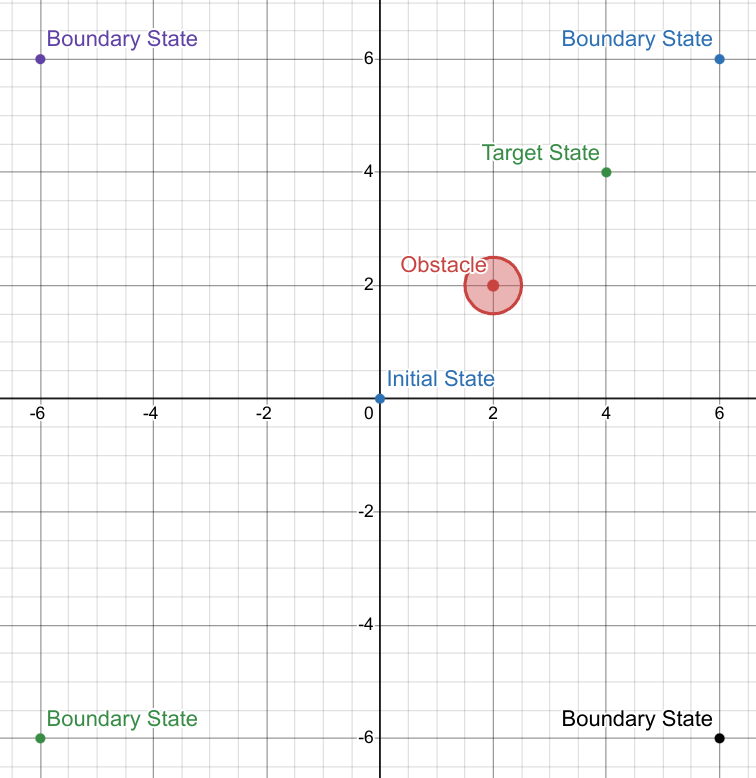

The image might give you a rough idea on what we are expecting.

# Use Monte Carlo Estimate:
Using Monte carlo estimate as,
\begin{align*}
    L(\theta)&= \frac{1}{a}\sum_{i=1}^{a} \max(0,-\rho_{\theta}(x_i)) + \frac{1}{b}\sum_{i=1}^{b} \max(0, \rho_{\theta}(y_i)) + \frac{1}{c}\sum_{i=1}^{c} \max(0, -\nabla . [(\rho_{\theta}f+ g \Psi_{\theta})(z_i)])\\
    &=\frac{1}{a}\sum_{i=1}^{a}\max(0,-\rho_{\theta}(0,0 ,\theta_i)) + \frac{1}{b}\sum_{i=1}^{b} \max(0, \rho_{\theta}(y_i)) + \frac{1}{c}\sum_{i=1}^{c} \max(0, -\nabla . [(\rho_{\theta}f+ g \Psi_{\theta})(z_i)])\\
\end{align*}


and the SMT constraint should be:
\begin{align*}
    \Phi_{\epsilon}(x):= \left( \sum_{i=1}^{n}x_i^2 \geq \epsilon \right) \wedge ( \rho_{x \in X_u}(x) \geq 0) \wedge (\rho_{x \in X_o}(x) < 0) \wedge ( \nabla . [ (\rho_{\theta}f+ g \Psi_{\theta})(x)] < 0)
\end{align*}

In [ ]:
import torch

torch.cuda.empty_cache()  # Clear the GPU memory cache


In [ ]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

import random

In [ ]:
torch.manual_seed(42)

random.seed()



In [ ]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the dynamics here:

In [ ]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x): 
    v=1
    val = torch.tensor([v* torch.cos(x[2],v * torch.sin(x[2],0))], device=device)
    return val


def g(x):
    return torch.tensor([0, 0 ,1], device=device)

